# General CESM Average Panels
### Take 2D or 3D climo output from CESM/obs/reanalysis and produce diagnostics:
### 1. `lat`     — Zonal average line plots (all cases on one figure)
### 2. `latlon`  — Lat-lon filled-contour map panels
### 3. `latpres` — Lat-pressure cross sections (full zonal mean, panel layout)
### 4. `lathgt`  — Lat-height cross sections with user-specified longitude range (panel layout) **NEW**
### 5. `vprf`    — Vertical profiles of domain-averaged 3D variable (all cases one figure) **NEW**
### 6. `bar2d`   — Regional average bar chart for 2D variable (all cases one figure) **NEW**

In [31]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as mp

import glob as glob
import os as os
import sys

from pathlib import Path

import cartopy.crs as ccrs

import importlib

# Allow imports from parent directory when running from Claude/
sys.path.insert(0, '..')
import general_cesm_plot_utils as mypy_utils
import general_vars_cases_figname as mypy_cases

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [33]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",
    cores=1,
    memory="8GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=8)
client = Client(cluster)

client

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35325 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/35325/status,
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/35325/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.100:39455,Workers: 0
Dashboard: /node/crhtc50.hpc.ucar.edu/45025/proxy/35325/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [34]:
# =====================================================================
#   SETTINGS
# =====================================================================

importlib.reload(mypy_cases)
importlib.reload(mypy_utils)


dir0      = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs   = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig   = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'

seas = 'DJF'

lfcase     = 5       # Case group selector (see general_vars_cases_figname.py)
lanom_plot = True    # True: icase=0 is control; subsequent cases show difference from control

# -------------------------------------------------------
## PLOT TYPE
#   'lat'     - Zonal average line plots (all cases on one figure)
#   'latlon'  - Lat-lon filled-contour map panel
#   'latpres' - Lat-pressure cross sections, full zonal mean (panel layout)
#   'lathgt'  - Lat-height cross sections over specified lon_ave range (panel layout)
#   'vprf'    - Vertical profiles of domain-averaged 3D var (all cases one figure)
#   'bar2d'   - Regional mean bar chart for 2D variable (all cases one figure)
# -------------------------------------------------------

plot_type = 'latpres'

# Longitude range used for zonal averaging in 'lat' and 'lathgt' plots
lon_ave = [0., 360.]

# Region name for 'latlon', 'latpres', 'lathgt' plots
# Options: Global, LabSea, IO, US, SAm, Aus, TP, WP, IndoPac, Tropics, EPac, Boreal, NPolar, SPolar
pregion = 'Global'

# Lat/lon domain for 'vprf' and 'bar2d' plots: [lat_min, lat_max, lon_min, lon_max]
domain_latlon = [2, 15, 240., 300.]   # e.g. Tropical Pacific


mask_ocn = False

# Vertical processing for 3D variables
#   'pvint' = mass-weighted vertical integral
#   'plevs' = interpolate to standard pressure levels
# Note: 'vprf' and 'lathgt' always force 'plevs' regardless of this setting
vproc = 'pvint'

# -------------------------------------------------------
# Load cases and variable from repository
# -------------------------------------------------------

dcases, var, obs_cases, fig_pref = mypy_cases.get_case_all(lfcase)

case_names = list(dcases.keys())
cases      = [v for v in dcases.values()]

vmask_ocn = ['SHFLX', 'LHFLX', 'TMQ', 'TAUY', 'TAUX']  # Masked over ocean by default

cases      = obs_cases + cases      if obs_cases != [''] else cases
case_names = obs_cases + case_names if obs_cases != [''] else case_names
nobs       = len(obs_cases)         if obs_cases != [''] else 0

ncases = len(cases)
pcases = ncases

obs_set = ['GPCP', 'TRMM', 'CERES2', 'CERES-EBAF', 'ERBE', 'ERAI', 'JRA25', 'MERRA',
           'LARYEA', 'WHOI', 'NVAP', 'ERS', 'SSMI', 'HadISST_PI', 'HadSST_PD']

# -------------------------------------------------------
# Validate settings
# -------------------------------------------------------

valid_plot_types = ['lat', 'latlon', 'latpres', 'lathgt', 'vprf', 'bar2d']
if plot_type not in valid_plot_types:
    print(f' **** UNRECOGNIZED PLOT TYPE. ALLOWED TYPES ARE - {valid_plot_types}')

if plot_type in ['latlon', 'latpres', 'lathgt']:
    pregions = ['NPolar', 'SPolar', 'LabSea', 'IO', 'US', 'SAm', 'Aus', 'TP',
                'WP', 'Tropics', 'IndoPac', 'EPac', 'Global', 'Boreal']
    if pregion not in pregions:
        print(' **** UNRECOGNIZED PLOT REGION. ALLOWED REGIONS ARE ...')
        print(pregions)

if 'plot_sub_nums' not in locals():
    plot_sub_nums = list(range(ncases))

** Too many panels for ncases

>>> Plotting Summary <<<
 *** Variable  = RELHUM
 *** Plot type = latpres
 *** Region    = Global
 *** Anomalies = True
 *** Season    = DJF

>>> Cases <<<
  - ERAI
  - f.e30.FLTHIST.CAM7.L58.000a
  - f.e22.FHIST.f09_f09.CAM6.L32.000
  - f.e30.FHISTC_WAt1ma.ne30pg3_mg17_L135_cam6_4_173_beres0.15_num_cin1
  - f.e30.FHISTC_WAt1ma.ne30pg3_mg17_L135_cam6_4_173_beres0.15_num_cin3

--- Case 1 of 5: ERAI ---
 - Opening dataset (Observations)
 - Configuring variable -
 - Processing variable ready for plotting - vproc=plevs, ndims=3, in_dims=('lev', 'lat', 'lon')
 - var_forplot returning: dims=('lev', 'lat', 'lon')
 - Plotting -
48.480438987733 55.88603885802334

--- Case 2 of 5: f.e30.FLTHIST.CAM7.L58.000a ---
 - Opening dataset (local climo)
 - Configuring variable -
 - Processing variable ready for plotting - vproc=plevs, ndims=3, in_dims=('lev', 'lat', 'lon')
 -Vertically average CAM dataset 
 - var_forplot returning: dims=('lat', 'lon', 'lev')
 - Plotting -
1

UnboundLocalError: cannot access local variable 'var_in' where it is not associated with a value

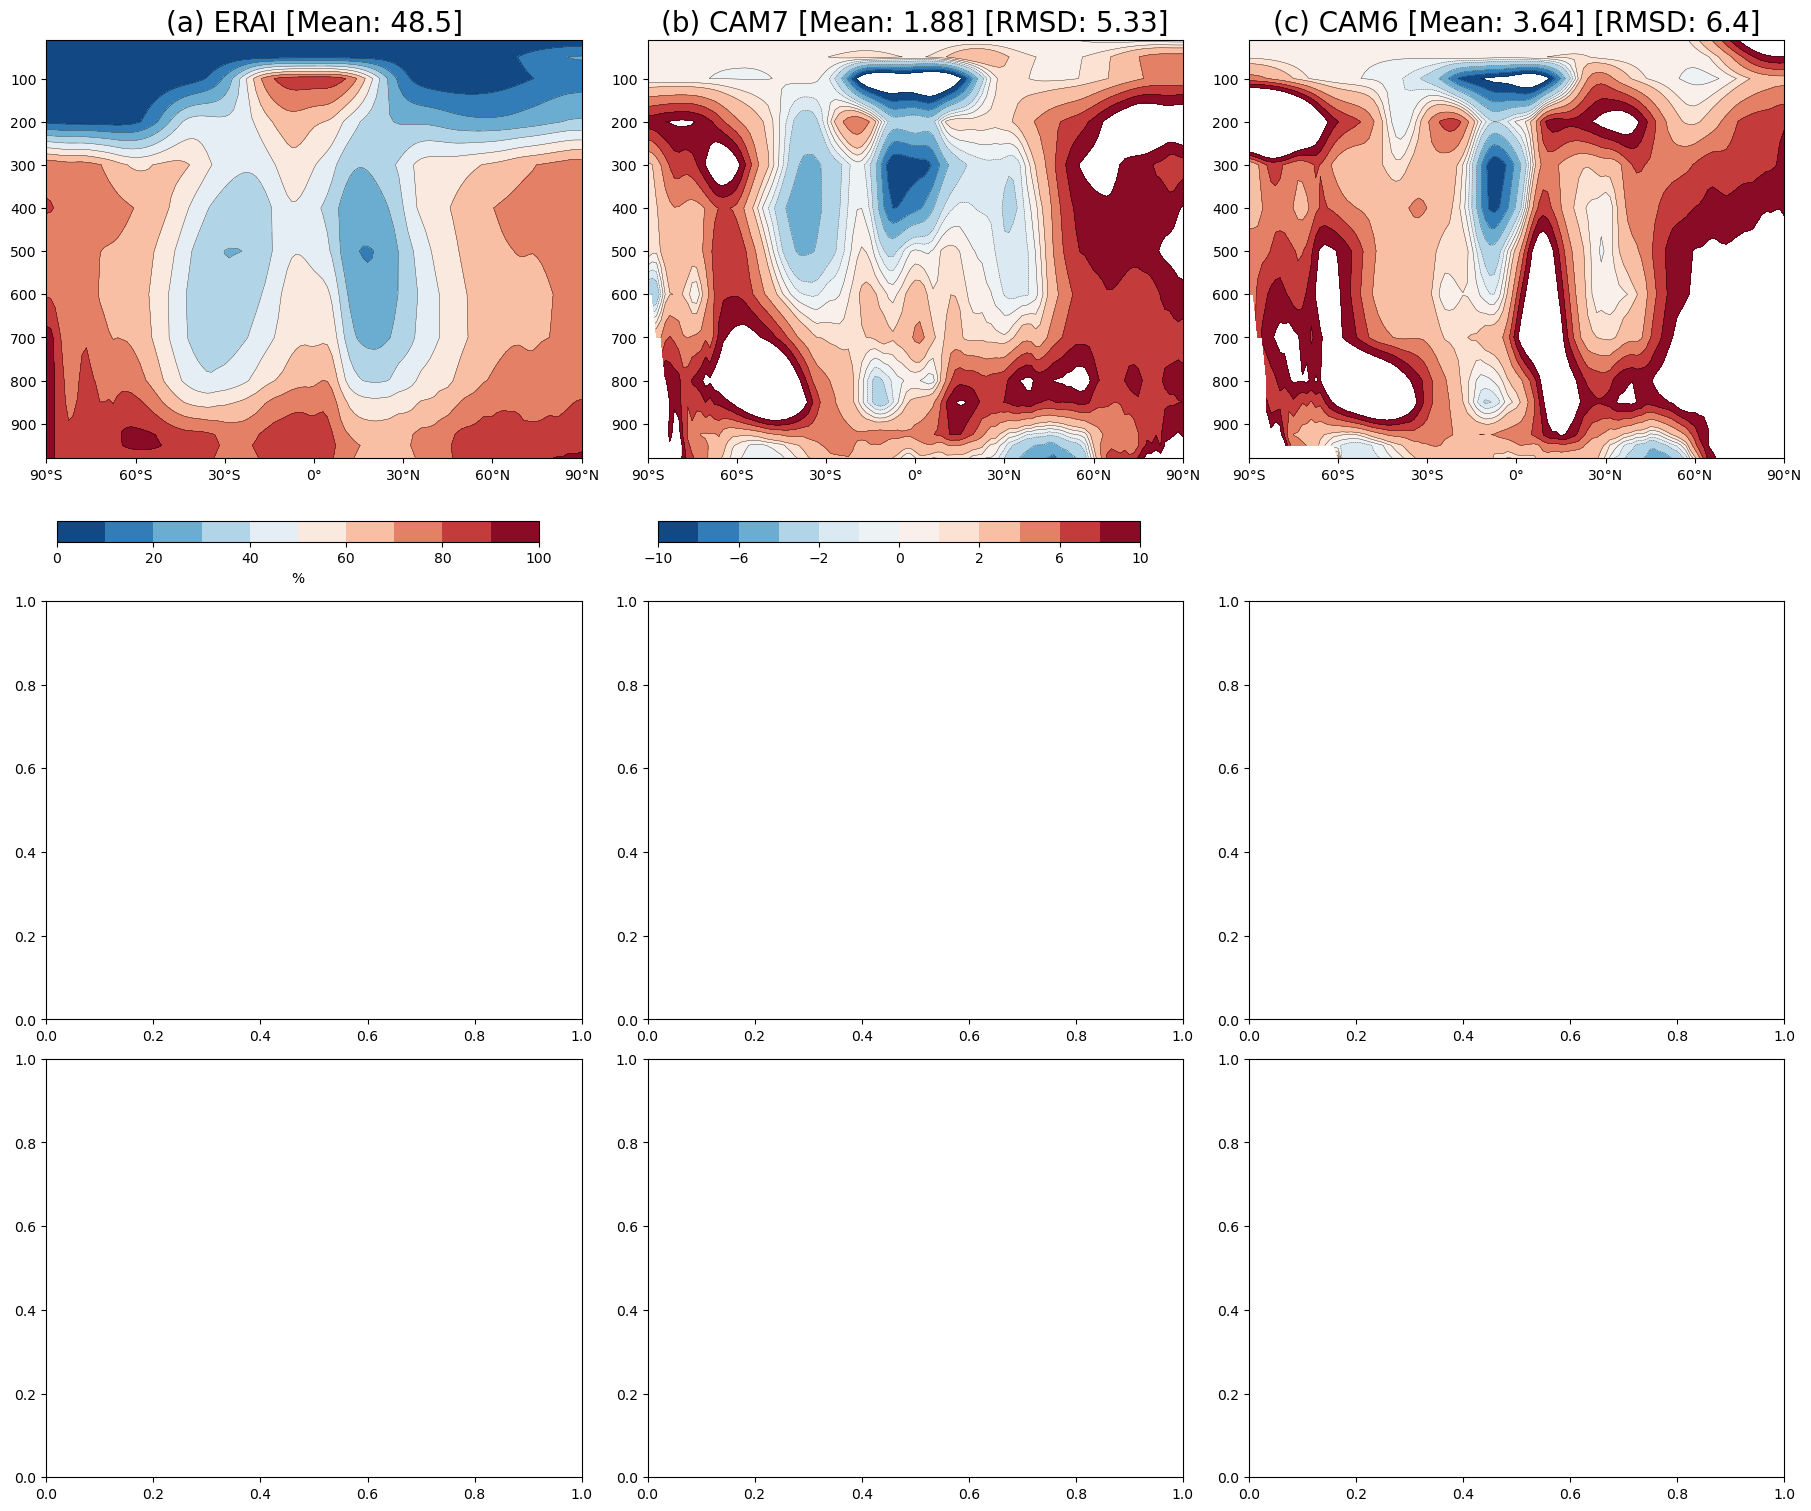

In [35]:
## %autoreload 2

# =====================================================================
# FIGURE SETUP  (choose layout based on plot_type)
# =====================================================================

match plot_type:

    case 'lat':
        nrows = 1
        ncols = 1
        fig, ax = mp.subplots(figsize=[12, 8])

    case 'latlon':
        nrows = 2
        ncols = 4
        ccrs_preg = (ccrs.Robinson(central_longitude=180.)
                     if pregion == 'Global' else ccrs.PlateCarree(central_longitude=180.))

        if pregion in ['NPolar', 'SPolar']:
            fig, axs = mp.subplots(
                nrows=nrows, ncols=ncols, figsize=[ncols*5, nrows*6.],
                subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0.)},
                constrained_layout=True)
        else:
            fig, axs = mp.subplots(
                nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*4.3],
                subplot_kw={'projection': ccrs_preg},
                constrained_layout=True)
        ax = axs.flatten()

    case 'latpres':
        nrows = 3
        ncols = 3
        fig, axs = mp.subplots(nrows=nrows, ncols=ncols,
                               figsize=[ncols*6, nrows*5], constrained_layout=True)
        ax = axs.flatten()

    case 'lathgt':
        # Same panel layout as latpres but zonal mean is over lon_ave range
        nrows = 3
        ncols = 3
        fig, axs = mp.subplots(nrows=nrows, ncols=ncols,
                               figsize=[ncols*6, nrows*5], constrained_layout=True)
        ax = axs.flatten()

    case 'vprf':
        # Single axis - all cases overplotted
        nrows = 1
        ncols = 1
        fig, ax = mp.subplots(figsize=[8, 10])

    case 'bar2d':
        # Single axis bar chart - collect means during loop, plot at last case
        nrows = 1
        ncols = 1
        fig, ax = mp.subplots(figsize=[max(8, ncases * 1.8), 7])
        bar2d_means = []


nsplots = nrows * ncols

if plot_type in ['latlon', 'latpres', 'lathgt']:
    if nrows * ncols > ncases: print('** Too many panels for ncases')
    if nrows * ncols < ncases: print('** Too few  panels for ncases')

print()
print('>>> Plotting Summary <<<')
print(' *** Variable  =', var)
print(' *** Plot type =', plot_type)
if plot_type in ['latlon', 'latpres', 'lathgt']:
    print(' *** Region    =', pregion)
if plot_type in ['lat', 'lathgt']:
    print(' *** Lon range =', lon_ave)
if plot_type in ['vprf', 'bar2d']:
    print(' *** Domain    =', domain_latlon)
print(' *** Anomalies =', lanom_plot)
print(' *** Season    =', seas)
print()
print('>>> Cases <<<')
print('\n'.join(f'  - {item}' for item in cases))


# =====================================================================
# MAIN LOOP
# =====================================================================

var_save     = None
nskip_panel  = -1
splots       = list(range(ncases))

if plot_type in ['latlon', 'latpres', 'lathgt'] and nskip_panel >= 0:
    ax[nskip_panel].set_visible(False)


for icase, case in enumerate(cases[0:pcases]):

    isplot     = splots[icase]
    cname      = case_names[icase]
    llast_case = icase == ncases - 1
    is_obs     = case in obs_set

    print()
    print(f'--- Case {icase+1} of {ncases}: {case} ---')

    # ------------------------------------------------------------------
    # File selection
    # ------------------------------------------------------------------
    if is_obs:
        case_file  = dir_obs + case + '_' + seas + '_climo.nc'
        climo_loc  = 'Observations'
    else:
        case_dir = Path(dir0 + case + '/climo')

        if case_dir.is_dir():
            climo_loc = 'local climo'
            case_file = dir0 + case + '/climo/' + case + '_' + seas + '_climo.nc'
        else:
            climo_loc = 'AMWG climo'
            case_file = glob.glob(dir_climo + case + '/*/' + case + '_' + var + '_climo.nc')
            if len(case_file) != 0:
                case_file = sorted(case_file, key=os.path.getmtime, reverse=True)[0]

    print(f' - Opening dataset ({climo_loc})')
    ds = xr.open_dataset(case_file, decode_times=False, chunks={}, engine='netcdf4')

    # ------------------------------------------------------------------
    # Variable metadata and extraction
    # ------------------------------------------------------------------
    var_info = mypy_utils.set_var_params(ds, var, case)

    

    var_from_file = var_info[var][case][1] if is_obs else var
    vscale        = var_info[var][case][0] if is_obs else var_info[var]['vscale']
    vunits        = var_info[var]['vunits']
    voffset       = 0.

    if not is_obs:
        voffset = var_info[var].get('voffset', 0.)

    var_in, ds = mypy_utils.getvar_derived(ds, var_from_file, seas)
    var_in     = var_in * vscale + voffset

    # ------------------------------------------------------------------
    # Optional ocean mask
    # ------------------------------------------------------------------
    if var in vmask_ocn:
        var_in = mypy_utils.apply_land_mask(ds, var_in)

    # ------------------------------------------------------------------
    # Process variable (anomalies, vertical handling)
    # ------------------------------------------------------------------
    print(' - Configuring variable -')

    # vprf and lathgt always need pressure-level interpolation, not vertical integral
    vproc_use = 'plevs' if plot_type in ['vprf', 'lathgt'] else vproc

    var_plot, var_save = mypy_utils.var_forplot(
        ds, var_in, var, var_save, icase, lanom_plot, is_obs, vproc_use)

    # Stats (only computed for 2D map plots where they appear in panel titles)
    if plot_type == 'latlon':
        case_stats = mypy_utils.case_stats_calc(var_plot, var_save, pregion, lanom_plot, icase)

    # ------------------------------------------------------------------
    # PLOTTING OPTIONS
    # ------------------------------------------------------------------
    print(' - Plotting -')

    # --- 1. Zonal Average (lat) ---
    if plot_type in ['lat', 'lon']:
        zonal_mean  = var_plot.sel(lon=slice(*lon_ave)).mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_lat(icase, case, obs_set, nobs)
        mypy_utils.plot_lat(ax, fig, icase, var, zonal_mean, vunits, cname, seas,
                            mask_ocn, lanom_plot, llast_case, params_plot)

    # --- 2. Lat-Lon Maps ---
    if plot_type == 'latlon':
        params_plot = mypy_utils.set_params_latlon(icase, ncases, var, obs_set, lanom_plot)
        mypy_utils.plot_latlon(ax[isplot], fig, icase, var, var_plot, case_stats,
                               vunits, cname, seas, pregion, mask_ocn, lanom_plot,
                               llast_case, params_plot)

    # --- 3. Lat-Pressure (full zonal mean) ---
    if plot_type in ['latpres', 'pres']:
        zonal_mean  = var_plot.mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_latpres(icase, ncases, var, obs_set, lanom_plot)
        mypy_utils.plot_latpres(ax[isplot], fig, icase, zonal_mean, vunits, cname,
                                seas, lanom_plot, llast_case, params_plot)

    # --- 4. Lat-Height (zonal mean over lon_ave range) ---
    if plot_type == 'lathgt':
        zonal_mean  = var_plot.sel(lon=slice(*lon_ave)).mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_latpres(icase, ncases, var, obs_set, lanom_plot)
        mypy_utils.plot_latpres(ax[isplot], fig, icase, zonal_mean, vunits, cname,
                                seas, lanom_plot, llast_case, params_plot)
        if llast_case:
            lon_str = f'{lon_ave[0]}-{lon_ave[1]}E'
            fig.suptitle(f'{var} ({lon_str} mean) - {seas}', fontsize=18, y=1.01)

    # --- 5. Vertical Profiles (domain average) ---
    if plot_type == 'vprf':
        lat_min, lat_max, lon_min, lon_max = domain_latlon
        var_dom  = var_plot.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
        gweights = np.cos(np.deg2rad(var_dom['lat']))
        gweights.name = 'weights'
        profile  = var_dom.weighted(gweights).mean(dim=('lat', 'lon'))
        params_plot = mypy_utils.set_params_lat(icase, case, obs_set, nobs)
        mypy_utils.plot_vprf(ax, fig, icase, var, profile, vunits, cname, seas,
                             domain_latlon, lanom_plot, llast_case, params_plot)

    # --- 6. Regional Bar Chart (2D field) ---
    if plot_type == 'bar2d':
        lat_min, lat_max, lon_min, lon_max = domain_latlon
        var_dom  = var_plot.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
        gweights = np.cos(np.deg2rad(var_dom['lat']))
        gweights.name = 'weights'
        reg_mean = float(var_dom.weighted(gweights).mean(dim=('lat', 'lon')).values)
        bar2d_means.append(reg_mean)

        if llast_case:
            mypy_utils.plot_bar2d(ax, fig, bar2d_means, case_names[:pcases],
                                  vunits, var, seas, domain_latlon, lanom_plot, obs_set)


# =====================================================================
# POST-LOOP: hide unused panels, save figure
# =====================================================================

if plot_type in ['latlon', 'latpres', 'lathgt']:
    for ix in range(ncases, nrows * ncols):
        ax[ix].set_visible(False)


print()
print('************')
print('* Finished *')
print('************')
print()

panom  = 'anom_' if lanom_plot else ''
panom  = panom + obs_cases[0] + '_' if obs_cases[0] != '' else panom

if plot_type in ['latlon', 'latpres', 'lathgt']:
    dom_str = pregion
elif plot_type in ['vprf', 'bar2d']:
    dom_str = f'{domain_latlon[0]}_{domain_latlon[1]}_{domain_latlon[2]}_{domain_latlon[3]}'
else:
    dom_str = f'lon{lon_ave[0]}-{lon_ave[1]}'

fig_file = (dir_fig + fig_pref + '_' + var + '_' + seas + '_'
            + dom_str + '_' + panom + plot_type + '_panel.png')

fig.savefig(fig_file, dpi=120, bbox_inches='tight')
fig.show()
print('Saved to:', fig_file)